### Gameplay

In this file, we will test different trained policies using a standard 52 card deck, using our different policies to play through the deck, and comparing average final payout.

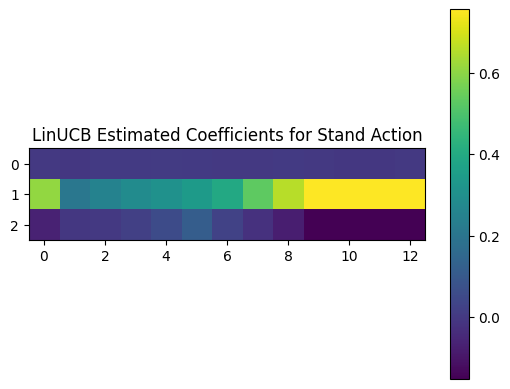

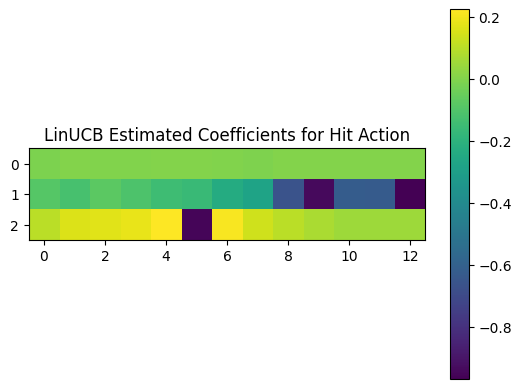

In [10]:
%run "linucb.ipynb"

LinUCB_betas = betas.copy() 

LinUCB with Buffered Rewards - Test

In [18]:
t = BlackjackTable()

rewards_history = []

for episode in range(10000):
    done = False
    state = t.reset()

    total_reward = 0

    while not done:
        if t._get_obs()['bet'] == 0:
            t.step((0,1))
            obs = t._get_obs()
            info = t._get_info()

        prev = interprethand(info['pastcards'])
        player = interprethand(obs['playercards'])
        dealer = interprethand(obs['dealercards'])
        x = np.concatenate((np.array([1]), prev, player, dealer))

        rewards = betas @ x
        action = np.argmax(rewards)

        obs, reward, done, _, info = t.step((1, action))
        
        total_reward += reward
    
    if (episode + 1) % 1000 == 0:
        print(f'Episode {episode+1}: Total Reward: {total_reward}')

    rewards_history.append(total_reward)

Episode 1000: Total Reward: 8
Episode 2000: Total Reward: 1
Episode 3000: Total Reward: 4
Episode 4000: Total Reward: 2
Episode 5000: Total Reward: 1
Episode 6000: Total Reward: 5
Episode 7000: Total Reward: 3
Episode 8000: Total Reward: 3
Episode 9000: Total Reward: 8
Episode 10000: Total Reward: 2


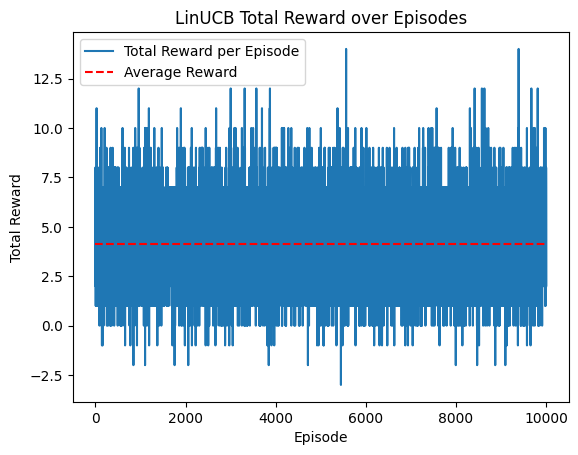

In [20]:
average_reward = np.mean(rewards_history)

plt.plot(rewards_history, label='Total Reward per Episode')
plt.hlines(average_reward, colors='r', linestyles='dashed', label='Average Reward', xmin=0, xmax=len(rewards_history))
plt.legend()
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('LinUCB Total Reward over Episodes')
plt.show()

Baseline: HW Value Iteration Naive Approach to maximize hand w/o busting

(a) Discount factor $\beta = 1$ with $r = hand-value$. Optimal policy:
- with usable ace: [1 1 1 1 1 0 0 0 0 0]
- without usable ace: [0 0 0 0 0 0 0 0 0 0]

(a) Discount factor $\beta = 1$ with $r = (hand-value)^2$. Optimal policy:
- with usable ace: [1 1 1 1 1 1 0 0 0 0]
- without usable ace: [1 1 0 0 0 0 0 0 0 0]

In [21]:
policy1 = np.ones([2,21])
policy1[0, -10:] = 0
policy1[1, -5:] = 0

policy2 = np.ones([2,21])
policy2[0, -8:] = 0
policy2[1, -4:] = 0

In [ ]:
#### NEED TO FIX - HAVE ENCODED POLICIES ABOVE - JUST NEED TO GET HAND VALUES & TRANSLATE TO ACTIONS BELOW ####


t = BlackjackTable()

value_iter_rewards_history = []

for episode in range(10000):
    done = False
    state = t.reset()

    total_reward = 0

    while not done:

        if t._get_obs()['bet'] == 0:
            t.step((0,1))
            obs = t._get_obs()
            info = t._get_info()

        hand_val = t.getValue()

        if np.any(obs['playercards'] == 1) and hand_val + 10 <= 21:
            action = int(policy2[1, hand_val])
        else:
            action = int(policy1[0, hand_val])

        obs, reward, done, info = t.step(action)        
        total_reward += reward
    
    if (episode + 1) % 1000 == 0:
        print(f'Episode {episode+1}: Total Reward: {total_reward}')

    rewards_history.append(total_reward)

NameError: name 'self' is not defined